In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from pymatgen.electronic_structure.core import Orbital, OrbitalType, Spin
from pymatgen.core.periodic_table import Element, Species

from CsBBX_Analyzer import SingleHDPanalysis, GroupedAnalysis
import time

#Import relevant data
basicinfofile = '/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/HDP_BasicInfo_251227.csv'
bandedgefile_vasp = '/home/lwalterb/hdp_project/NewWF_Analysis/AnalysisResultsPsiK/HDP_bandedgeInfo_vaspdos_220825.csv'
bandedgefile_lso = '/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/HDP_bandedgeInfo_lsodos_251227.csv'
bandedgefile_lobster = '/home/lwalterb/hdp_project/NewWF_Analysis/AnalysisResultsPsiK/HDP_bandedgeInfo_lobsterdos_220825.csv'
magmomfile_loewdin = '/home/lwalterb/hdp_project/NewWF_Analysis/AnalysisResultsPsiK/HDP_MagmomInfo_Loewdin_220825.csv'


qualityoverviewfile = '/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/HDP_lobqual_overview_251227.csv'
largespillfile = '/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/HDPs_SpillOver3_251227.csv'

output_dir = '/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis'

/home/lwalterb/hdp_project/NewWF_Analysis/CsBBX_Analyzer.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


hello0


In [2]:
##Import quality analysis from saved csv
quality_df = pd.read_csv(qualityoverviewfile, index_col=[0,1])

##import which comps have charge spilling > 3% in basis0
b0qual_df = quality_df.xs('basisset0',level=1)
badqualcomps = pd.read_csv(largespillfile,index_col=[0,1])

In [3]:
##Collect the quality of the basis actually used
usedqual = b0qual_df.reset_index().set_index('comp').copy()

for comp in badqualcomps.index.get_level_values(0):
    pos_choices = badqualcomps.loc[comp]
    corr_basis = pos_choices[pos_choices['abs_charge_spilling']== pos_choices['abs_charge_spilling'].min()].index.to_list()[0]
    usedqual.loc[comp] = quality_df.loc[(comp,corr_basis)]

print(usedqual.shape)
print(b0qual_df.shape)

(2583, 4)
(2583, 4)


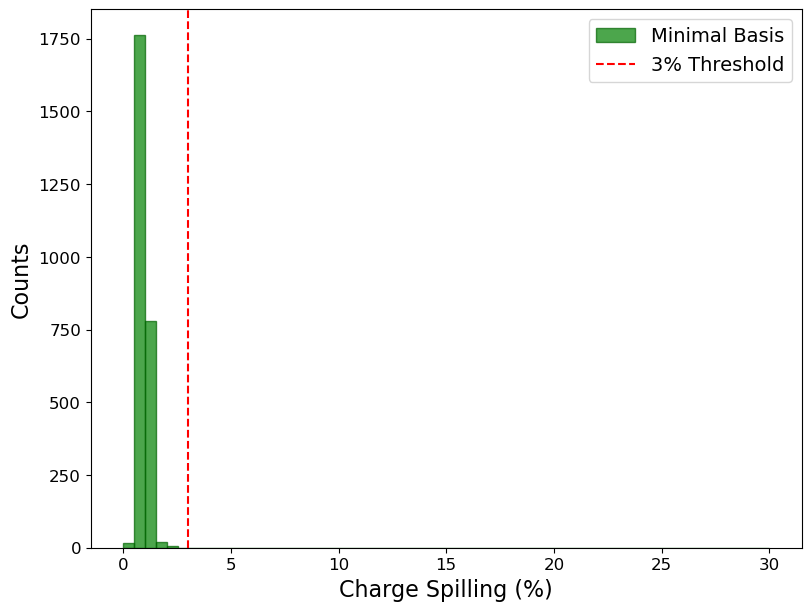

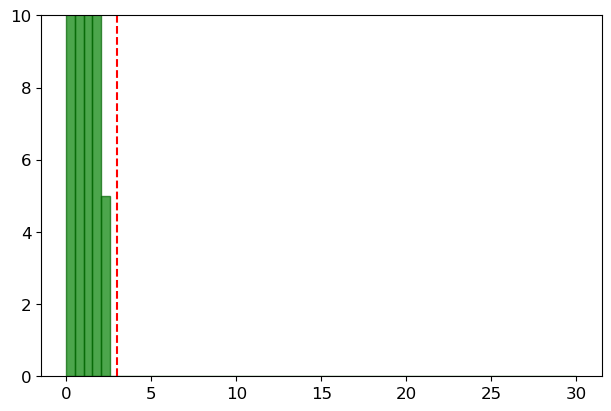

In [4]:
##Plot the charge spilling for each comp
plt.rcParams.update({
    "text.usetex": False, "font.family":"sans-serif","xtick.labelsize":12,"ytick.labelsize":12})
plt.figure(figsize=(8, 6),layout='constrained')
binning = np.linspace(0,30,60)
plt.hist('abs_charge_spilling', color='green',bins=binning, linewidth=1.,edgecolor='darkgreen', data=usedqual, alpha=0.7, label='Minimal Basis')
# plt.hist('abs_charge_spilling', color='blue',bins=binning, data=b0qual_df,alpha=0.1, facecolor='red',linewidth=1.3,edgecolor='red', linestyle= '--' , label='Min. Basis only')
plt.axvline(x=3, color='red', linestyle='--', label='3% Threshold')
plt.ylabel('Counts', fontsize=16)
plt.xlabel('Charge Spilling (%)', fontsize=16)
# plt.title('Charge Spilling in LOBSTER projection', fontsize=16)
leg = plt.legend(fontsize=14)
# plt.tight_layout()
plt.savefig(f'{output_dir}/LobQualHist_{time.strftime("%d%m%y")}.png')
plt.show()

#zoomed in plot
plt.figure(figsize=(6, 4),layout='constrained')
binning = np.linspace(0,30,60)
plt.hist('abs_charge_spilling', color='green',bins=binning, data=usedqual,linewidth=1.,edgecolor='darkgreen', alpha=0.7, label='Minimal Basis')
# plt.hist('abs_charge_spilling', color='blue',bins=binning, data=b0qual_df,alpha=0.1, facecolor='red',linewidth=1.3,edgecolor='red', linestyle= '--' , label='Min. Basis only')
plt.axvline(x=3, color='red', linestyle='--', label='3% Threshold')
# plt.ylabel('Counts', fontsize=16)
# plt.xlabel('Charge Spilling (%)', fontsize=16)
# plt.tight_layout()
plt.ylim([0,10])
plt.savefig(f'{output_dir}/LobQualHist_zoom_{time.strftime("%d%m%y")}.png')
plt.show()


In [5]:
# basicdf = pd.read_csv(basicinfofile, index_col=0)
# magmomdf = pd.read_csv(magmomfile_loewdin, index_col=0)
# comb_info = pd.concat([basicdf,dband_vasp.xs('combined',level=1),magmomdf],axis=1)

def plot_bgmagmom(combined_info:pd.DataFrame, bandgap_df:pd.DataFrame, suptitle:str |None = None, filename:str|None=None, use_lob_pop:bool=False):    
    plt.rcParams.update({
    "text.usetex": True, "font.family":"Helvetica","xtick.labelsize":16,"ytick.labelsize":16,
    'legend.handletextpad':0.4, "legend.handlelength": 0.6, "legend.columnspacing":0.8})
    #combine all info into one DF for plotting
    

    #we also want to plot the minority spin gap in half-metals
    halfm_index = combined_info[combined_info['cond_type'] == "half-metal"].index
    hm_channel_gaps = bandgap_df.loc[halfm_index].drop('combined',level=1)
    secondary_gaps = hm_channel_gaps[hm_channel_gaps['cond_type'] != 'metallic']        

    metallic_index = combined_info[combined_info['cond_type']=='metallic'].index


    ##Start plotting
    fig, axes = plt.subplots(2,2, sharex='col', sharey='row',figsize=(8,8), width_ratios=(3,1), height_ratios=(1,3),layout='constrained')

    ##plot histogram of bandgaps
    bg_binning = [0.0,0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75, 10.0, 10.25]
    axes[0][0].hist('bandgap', color="#198B15E2",bins=bg_binning, data=combined_info.drop(metallic_index).drop(halfm_index), alpha=0.7, label='Bandgap values')
    axes[0][0].hist('bandgap', color="#8D800BDF",bins=bg_binning, data=combined_info[combined_info['cond_type']=='metallic'], alpha=1, label='Metallic($E_{g}\leq$ 0.1 eV)')
    axes[0][0].hist('bandgap', color="#4C1D72FB",bins=bg_binning, data=secondary_gaps, alpha=0.7, label='Half-metal gaps')
    axes[0][0].set_ylabel('Counts', fontsize=16)
    axes[0][0].set_ylim([0,55])
    # axes[0][0].set_xlabel('Bandgap (eV)',fontsize=14)

    # axes[0][0].set_title('Bandgap counts', fontsize=16)
    axes[0][0].legend(fontsize=15)

    axes[0][1].axis('off')



    #plot histogram of magmom0
    magmom_binning = np.arange(0,13,1)
    axes[1][1].hist(abs(combined_info['magmom_tot_vasp']), color="#001D7C9B",bins=magmom_binning, alpha=0.7, align='left',label='Net polarization',orientation ='horizontal')
    # axes[1][1].set_ylabel('Mag. moment ($\\mu_B$)',fontsize=14)
    axes[1][1].set_xlabel('Counts', fontsize=16)
    axes[1][1].set_xlim([0,350])
    # axes[1][1].set_title('Magmom counts', fontsize=16)
    # axes[1][1].legend(fontsize=13)


    #Plot scatter of magmom vs. bg
    #determe whether to use vasp or lob magmom
    if use_lob_pop:
        print('using lob magmom')
        magmom_key = 'popdiff_tot_lobster'
    else:
        magmom_key = 'magmom_tot_vasp'

    allpairings = ['Vac-d', 'Vac-f', 'Vac-p', 'Vac-dummy', 'd-d', 'd-f', 'd-p', 'd-s', 'f-f', 'f-p', 'f-s', 'f-dummy', 'p-p', 'p-s', 'p-dummy1','p-dummy2','s-s']
    colorings = { label:color for label, color in zip(allpairings, colormaps['tab20c'].colors)}
    pair_groups = combined_info.groupby('block_pairing')
    for pair in pair_groups.groups.keys():
        data = pair_groups.get_group(pair)
        axes[1][0].scatter(data['bandgap'], abs(data[magmom_key]), marker='h',s=38, color=colorings[pair],alpha=0.6,label=pair)
    axes[1][0].set_xlabel('Bandgap [eV]',fontsize=16)
    axes[1][0].set_ylabel('Net. Spin ($n(\\uparrow) - n(\\downarrow) $)',fontsize=16) 
    leg = axes[1][0].legend(fontsize=16,ncols=3,alignment='right') 
    axes[1][0].set_ylim([-0.2,14.2])
    axes[1][0].set_xlim([-0.1,10.3])
    # plt.show()

    if suptitle:
        fig.suptitle(suptitle,fontsize=28)

    if filename:
        plt.savefig(filename, dpi=200)
    else:
        plt.show()

    # combined_info.head(10)
    return
# dband_vasp.xs('combined',level=1).head()




FileNotFoundError: [Errno 2] No such file or directory: '/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/magmom_bg_plots/MAGMOMvBG_X_F_vaspdos.png'

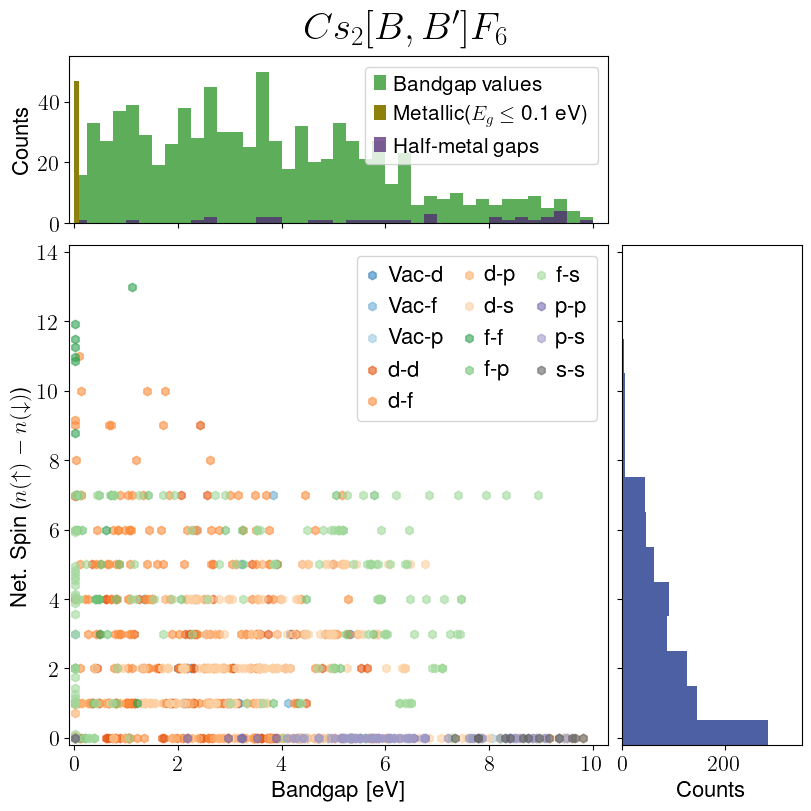

In [8]:
basicdf = pd.read_csv(basicinfofile, index_col=0)
magdf = pd.read_csv(magmomfile_loewdin,index_col=0)

banddf_vasp = pd.read_csv(bandedgefile_vasp,index_col=[0,1])
banddf_lso = pd.read_csv(bandedgefile_lso, index_col=[0,1])
banddf_lobster = pd.read_csv(bandedgefile_lobster, index_col=[0,1])
dos_extensions = ['vaspdos', 'lsodos', 'lobsterdos']

def combine_dfs(banddf:pd.DataFrame, magmomdf:pd.DataFrame,basicdf:pd.DataFrame):    
    metallic_index = banddf[banddf['bandgap'] <= 0.1].index
    semicond_index = banddf[(banddf['bandgap'] > 0.1)&(banddf['bandgap']<5.0)].index
    ins_index = banddf[banddf['bandgap'] >= 5.].index


    banddf.loc[metallic_index,'cond_type'] = 'metallic'
    banddf.loc[semicond_index,'cond_type'] = 'semiconductor'
    banddf.loc[ins_index,'cond_type'] = 'insulator'
    # banddf.head(30)

    ##Track down half-metals
    for comp in banddf.index.get_level_values(0):

        if banddf.loc[(comp, 'combined')]['cond_type'] == 'metallic' and (banddf.loc[(comp, str(Spin.up))]['cond_type'] != 'metallic' or banddf.loc[(comp, str(Spin.down))]['cond_type'] != 'metallic'):
            banddf.loc[(comp,'combined'),'cond_type'] = 'half-metal'

    comb_df = pd.concat([basicdf,banddf.xs('combined',level=1),magmomdf],axis=1,join='inner')
    # print(comb_df.head())
    return comb_df

ii=0
for bandinfo in [banddf_vasp,banddf_lso, banddf_lobster]:
    # print(bandinfo.head())
    # print(magdf.head())
    # print(basicdf.head())
    
    comb_df = combine_dfs(banddf=bandinfo, magmomdf=magdf, basicdf=basicdf)
    comb_df.to_csv(f"{output_dir}/CombinedHDPinfo_{dos_extensions[ii]}.csv")

    for xsite in ['F','Cl','Br','I']:
        plotname = f'{output_dir}/magmom_bg_plots/MAGMOMvBG_X_{xsite}_{dos_extensions[ii]}.png'
        plottitle = f"$Cs_2[B,B']{xsite}_6$"

        if dos_extensions[ii] == 'lobsterdos':
            use_lobpop = True
        else:
            use_lobpop = False

        xsite_df = comb_df[comb_df['element.X']==xsite]
        # print(xsite_df.head())
        # xsite_df.head()

        _ = plot_bgmagmom(xsite_df,bandinfo,plottitle,plotname,use_lob_pop=use_lobpop)
    
    ii+=1


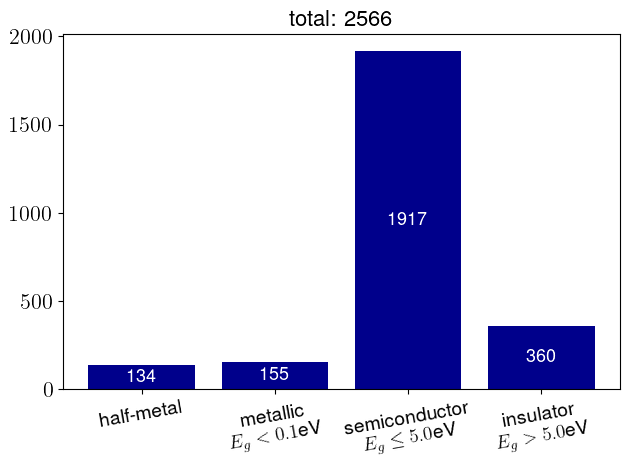

In [ ]:
combined_vasp = pd.read_csv('/home/lwalterb/hdp_project/NewWF_Analysis/AnalysisResultsPsiK/CombinedHDPinfo_vaspdos.csv',index_col=0)
cond_grouped = combined_vasp.groupby('cond_type')
counting = cond_grouped.count()['elementA']
labels = ['half-metal','metallic \n$E_{g}<0.1$eV',  'semiconductor\n$E_{g}\leq5.0$eV', 'insulator\n$E_{g}>5.0$eV']
keys = ['half-metal','metallic',  'semiconductor', 'insulator']

fig, ax = plt.subplots()
for label,key in zip(labels,keys):
    p = ax.bar(label,counting[key],facecolor='darkblue')
    ax.bar_label(p,label_type='center',color='w',fontsize=13)

ax.set_title(f"total: {np.sum(counting)}",fontsize=16)
plt.xticks(rotation=10,fontsize=14)
fig.tight_layout()
plt.savefig(f'{output_dir}/CondTypeCounts_{time.strftime("%d%m%y")}.png',dpi=200)
plt.show()

In [ ]:
combined_vasp['popdiff_tot_lobster'].idxmax()

'1864_CsGeAmF'

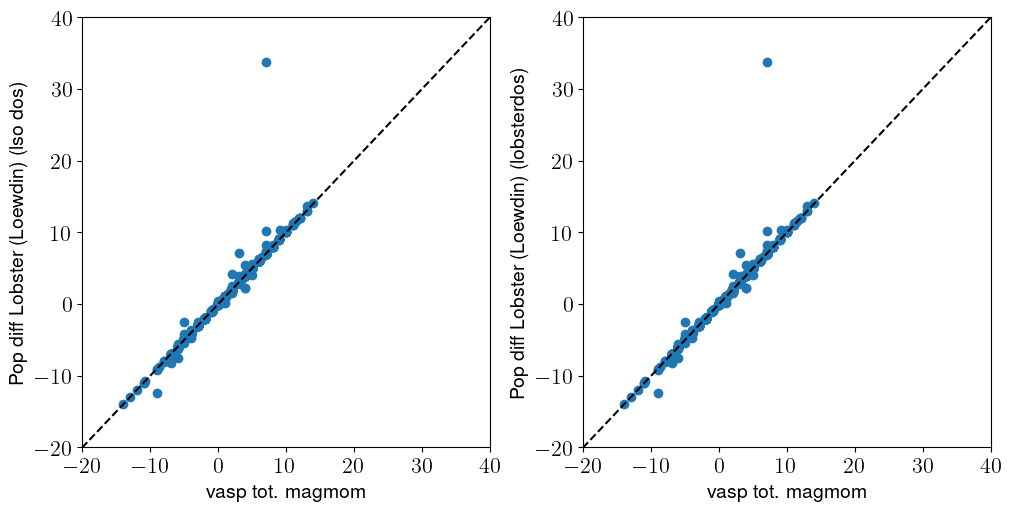

In [9]:
combined_vasp = pd.read_csv('/home/lwalterb/hdp_project/NewWF_Analysis/AnalysisResultsPsiK/CombinedHDPinfo_vaspdos.csv',index_col=0)
combined_lso = pd.read_csv('/home/lwalterb/hdp_project/NewWF_Analysis/AnalysisResultsPsiK/CombinedHDPinfo_lsodos.csv',index_col=0)
combined_lob = pd.read_csv('/home/lwalterb/hdp_project/NewWF_Analysis/AnalysisResultsPsiK/CombinedHDPinfo_lobsterdos.csv',index_col=0)

cond_grouped = combined_vasp.groupby('cond_type')
counting = cond_grouped.count()['elementA']
labels = ['half-metal','metallic \n$E_{g}<0.1$eV',  'semiconductor\n$E_{g}\leq5.0$eV', 'insulator\n$E_{g}>5.0$eV']
keys = ['half-metal','metallic',  'semiconductor', 'insulator']

fig, ax = plt.subplots(1,2, figsize=(10,5),layout='constrained')
ax[0].scatter(combined_vasp['magmom_tot_vasp'], combined_lso['popdiff_tot_lobster'])
ax[0].plot(np.linspace(-50,50),np.linspace(-50,50),'k--')
ax[0].set_xlabel('vasp tot. magmom',fontsize=14)
ax[0].set_ylabel('Pop diff Lobster (Loewdin) (lso dos)',fontsize=14)
ax[0].set_xlim([-20,40])
ax[0].set_ylim([-20,40])

ax[1].scatter(combined_vasp['magmom_tot_vasp'], combined_lob['popdiff_tot_lobster'])
ax[1].plot(np.linspace(-50,50),np.linspace(-50,50),'k--')
ax[1].set_xlabel('vasp tot. magmom',fontsize=14)
ax[1].set_ylabel('Pop diff Lobster (Loewdin) (lobsterdos)',fontsize=14)
ax[1].set_xlim([-20,40])
ax[1].set_ylim([-20,40])

plt.show()

In [17]:
new_basicdf = pd.read_csv('/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/HDP_BasicInfo_251227.csv', index_col=0).sort_index()
lobdatadf = pd.read_csv('/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/HDP_LobsterInfo_260106.csv',index_col=0).sort_index().fillna(0)
edgedf = pd.read_csv('/home/lwalterb/hdp_project/NewWF_Analysis/DecemberAnalysis/HDP_bandedgeInfo_lsodos_251227.csv',index_col=[0,1]).xs('combined',level=1).sort_index()

# edgedf = edgedf.drop("1820_CsTaHgF",axis=0)
lobdatadf = lobdatadf.drop_duplicates()

print(new_basicdf.shape)
print(lobdatadf.shape)
print(edgedf.shape)



corr_df = pd.concat([new_basicdf,lobdatadf,edgedf],axis=1,join='inner')
corr_df.head()

# corr_df = corr_df[corr_df['used_lobbasis']=='basis0']
print(corr_df.columns)

corr_df = corr_df.drop(corr_df[corr_df['charge.balanced']== False].index)
print(corr_df.shape)

(2583, 20)
(2583, 72)
(2583, 46)
Index(['compID_num', 'comp_name_simple', 'comp_name_full', 'specie.A',
       'specie.B1', 'specie.B2', 'specie.X', 'element.A', 'element.B1',
       'element.B2',
       ...
       'VBMorborder.X', 'VBMorbcontr.X', 'CBMtotcontr.X', 'CBMorbital.X',
       'CBMorbchar.X', 'CBMorborder.X', 'CBMorbcontr.X', 'spin_vbm',
       'spin_cbm', 'spin_forbidden'],
      dtype='object', length=138)
(2583, 138)


['Vac-d', 'Vac-f', 'Vac-p', 'd-d', 'd-f', 'd-p', 'd-s', 'f-f', 'f-p', 'f-s', 'p-p', 'p-s', 's-s']
Index(['1032_CsTlAlCl', '1131_CsTlAsCl', '1139_CsTlPCl', '1179_CsGePbCl',
       '1209_CsTlGaCl', '1430_CsTlBCl', '1445_CsTlSbCl', '1518_CsTlInCl',
       '1833_CsGePbF', '1866_CsPTlF', '2021_CsAlTlF', '2056_CsBTlF',
       '2105_CsAsTlF', '2179_CsGaTlF', '2245_CsNTlF', '2386_CsSbTlF',
       '2441_CsInTlF', '2692_CsTlBiF', '2739_CsAlTlBr', '2798_CsAsTlBr',
       '2864_CsGaTlBr', '2914_CsPTlBr', '2940_CsGePbBr', '3107_CsSbTlBr',
       '3181_CsInTlBr', '3183_CsBTlBr', '3423_CsAsTlI', '3492_CsGaTlI',
       '3505_CsAlTlI'],
      dtype='object', name='comp')


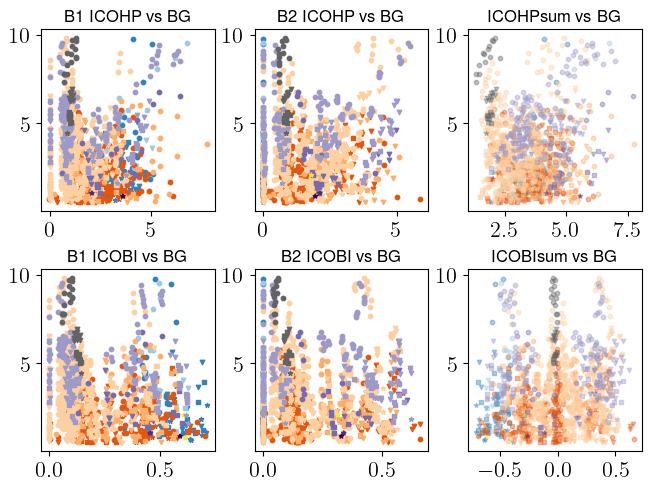

In [26]:
fig,ax = plt.subplots(2,3,layout='constrained')
allpairings = ['Vac-d', 'Vac-f', 'Vac-p', 'Vac-dummy', 'd-d', 'd-f', 'd-p', 'd-s', 'f-f', 'f-p', 'f-s', 'f-dummy', 'p-p', 'p-s', 'p-dummy1','p-dummy2','s-s']
colorings = { label:color for label, color in zip(allpairings, colormaps['tab20c'].colors)}
symbols = {'F':'o','Cl':'v','Br':'s','I':'*'}
ms=10
plot_df = corr_df[(corr_df['bandgap'] > 0.5) ]
pair_groups = plot_df.groupby('block_pairing')
print(list(pair_groups.groups.keys()))
for pair in list(pair_groups.groups.keys()):
    if 'f' in pair:
        continue

    blockdata = pair_groups.get_group(pair)
    xel_groups = blockdata.groupby('element.X')
    for xel in list(xel_groups.groups.keys()):
        if xel not in ['F','Cl', 'I','Br']:
            continue
        data = xel_groups.get_group(xel)
        ax[0,0].scatter(-data['Icohp.B1.avg'],data['bandgap'],c=colorings[pair],s =ms,marker=symbols[xel])
        ax[0,0].set_title('B1 ICOHP vs BG')

        ax[0,1].scatter(-data['Icohp.B2.avg'],data['bandgap'],c=colorings[pair],s =ms,marker=symbols[xel])
        ax[0,1].set_title('B2 ICOHP vs BG')

        ax[0,2].scatter(-data['Icohp.B2.avg']-data['Icohp.B1.avg'],data['bandgap'],c=colorings[pair],s =ms,marker=symbols[xel],alpha=0.4)
        ax[0,2].set_title('ICOHPsum vs BG')

        ax[1,0].scatter(data['Icobi.B1.avg'],data['bandgap'],c=colorings[pair],s =ms,marker=symbols[xel])
        ax[1,0].set_title('B1 ICOBI vs BG')

        ax[1,1].scatter(data['Icobi.B2.avg'],data['bandgap'],c=colorings[pair],s =ms,marker=symbols[xel])
        ax[1,1].set_title('B2 ICOBI vs BG')

        ax[1,2].scatter(data['Icobi.B2.avg']-data['Icobi.B1.avg'],data['bandgap'],c=colorings[pair],s =ms,marker=symbols[xel],alpha=0.4)
        ax[1,2].set_title('ICOBIsum vs BG')

print(pair_groups.get_group('p-p').index) 
# plt.savefig('/home/lwalterb/hdp_project/NewWF_Analysis/coxxbg_test_dpairs_noF.png',dpi=250)   



['Vac-d', 'Vac-f', 'Vac-p', 'd-d', 'd-f', 'd-p', 'd-s', 'f-f', 'f-p', 'f-s', 'p-p', 'p-s', 's-s']
p-p
p-s
s-s


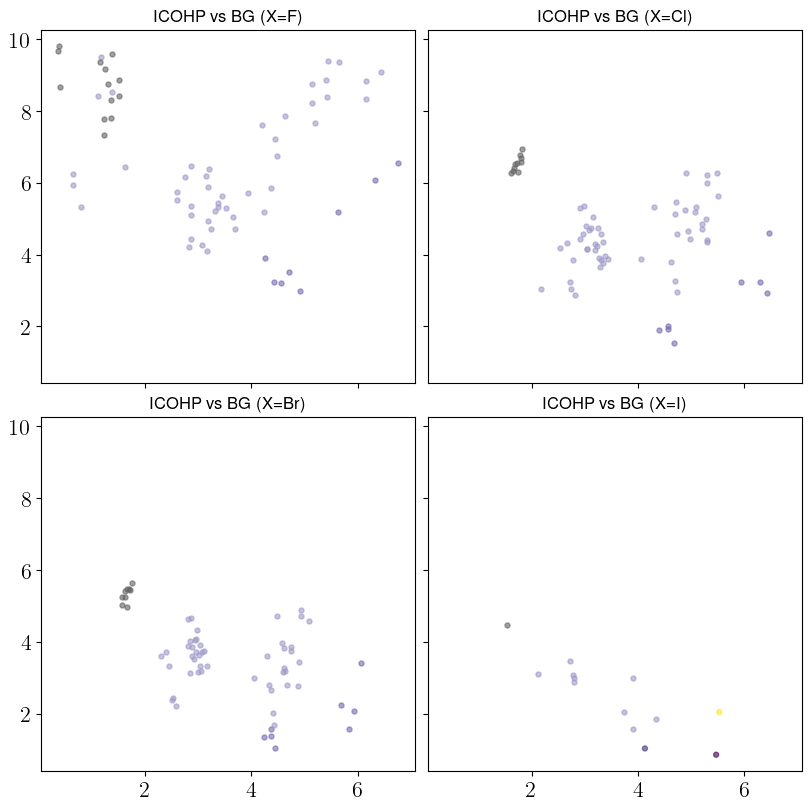

In [12]:
fig,ax = plt.subplots(2,2,layout='constrained',sharex=True,sharey=True,figsize=(8,8))
allpairings = ['Vac-d', 'Vac-f', 'Vac-p', 'Vac-dummy', 'd-d', 'd-f', 'd-p', 'd-s', 'f-f', 'f-p', 'f-s', 'f-dummy', 'p-p', 'p-s', 'p-dummy1','p-dummy2','s-s']
colorings = { label:color for label, color in zip(allpairings, colormaps['tab20c'].colors)}
symbols = {'F':'o','Cl':'v','Br':'s','I':'*'}
ms=13
plot_df = corr_df[(corr_df['bandgap'] > 0.5) ]
pair_groups = plot_df.groupby('block_pairing')
print(list(pair_groups.groups.keys()))
for pair in list(pair_groups.groups.keys())[-3:]:
    if '' not in pair:
        continue

    data = pair_groups.get_group(pair)
    print(pair)


    ax[0,0].scatter(-data[data['elementX']=='F']['B2.ICOHP_mean']-data[data['elementX']=='F']['B1.ICOHP_mean'],data[data['elementX']=='F']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[0,0].set_title('ICOHP vs BG (X=F)')


    ax[0,1].scatter(-data[data['elementX']=='Cl']['B2.ICOHP_mean']-data[data['elementX']=='Cl']['B1.ICOHP_mean'],data[data['elementX']=='Cl']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[0,1].set_title('ICOHP vs BG (X=Cl)')


    ax[1,0].scatter(-data[data['elementX']=='Br']['B2.ICOHP_mean']-data[data['elementX']=='Br']['B1.ICOHP_mean'],data[data['elementX']=='Br']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[1,0].set_title('ICOHP vs BG (X=Br)')


    ax[1,1].scatter(-data[data['elementX']=='I']['B2.ICOHP_mean']-data[data['elementX']=='I']['B1.ICOHP_mean'],data[data['elementX']=='I']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[1,1].set_title('ICOHP vs BG (X=I)')



# plt.savefig('/home/lwalterb/hdp_project/NewWF_Analysis/coxxbg_test_dpairs_noF.png',dpi=200)   



['Vac-d', 'Vac-f', 'Vac-p', 'd-d', 'd-f', 'd-p', 'd-s', 'f-f', 'f-p', 'f-s', 'p-p', 'p-s', 's-s']
Vac-d
Vac-p
d-d
d-p
d-s
p-p
p-s
s-s


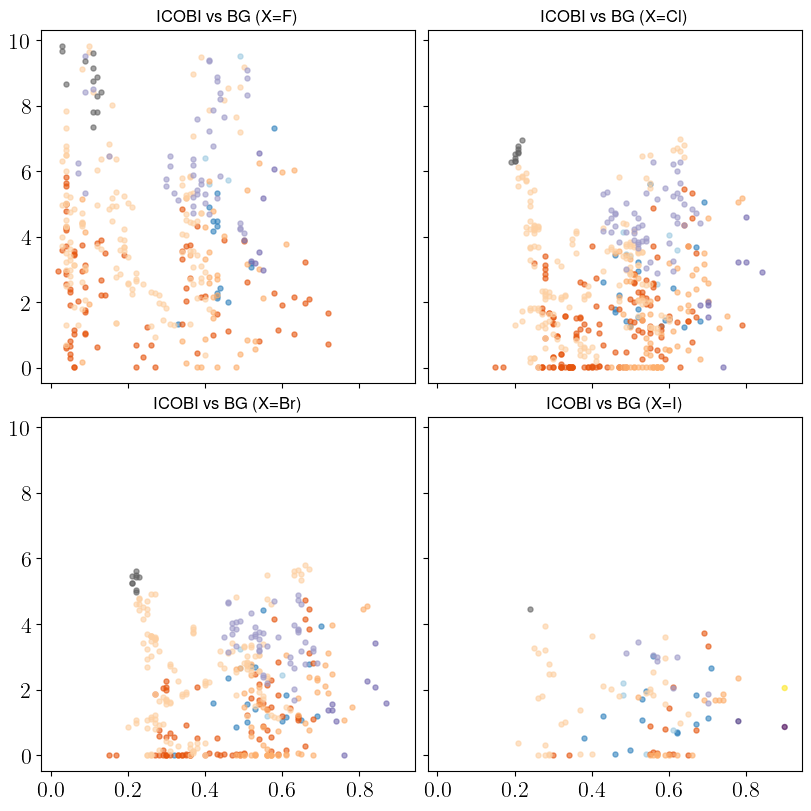

In [13]:
fig,ax = plt.subplots(2,2,layout='constrained',sharex=True,sharey=True,figsize=(8,8))
allpairings = ['Vac-d', 'Vac-f', 'Vac-p', 'Vac-dummy', 'd-d', 'd-f', 'd-p', 'd-s', 'f-f', 'f-p', 'f-s', 'f-dummy', 'p-p', 'p-s', 'p-dummy1','p-dummy2','s-s']
colorings = { label:color for label, color in zip(allpairings, colormaps['tab20c'].colors)}
symbols = {'F':'o','Cl':'v','Br':'s','I':'*'}
ms=13
plot_df = corr_df[(corr_df['bandgap'] > 0.0) ]
pair_groups = plot_df.groupby('block_pairing')
print(list(pair_groups.groups.keys()))
for pair in list(pair_groups.groups.keys())[:]:
    if 'f' in pair:
        continue

    data = pair_groups.get_group(pair)
    print(pair)


    ax[0,0].scatter(data[data['elementX']=='F']['B2.ICOBI_mean']+data[data['elementX']=='F']['B1.ICOBI_mean'],data[data['elementX']=='F']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[0,0].set_title('ICOBI vs BG (X=F)')


    ax[0,1].scatter(data[data['elementX']=='Cl']['B2.ICOBI_mean']+data[data['elementX']=='Cl']['B1.ICOBI_mean'],data[data['elementX']=='Cl']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[0,1].set_title('ICOBI vs BG (X=Cl)')


    ax[1,0].scatter(data[data['elementX']=='Br']['B2.ICOBI_mean']+data[data['elementX']=='Br']['B1.ICOBI_mean'],data[data['elementX']=='Br']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[1,0].set_title('ICOBI vs BG (X=Br)')


    ax[1,1].scatter(data[data['elementX']=='I']['B2.ICOBI_mean']+data[data['elementX']=='I']['B1.ICOBI_mean'],data[data['elementX']=='I']['bandgap'],c=colorings[pair],s =ms,marker='o',alpha=0.6)
    ax[1,1].set_title('ICOBI vs BG (X=I)')



# plt.savefig('/home/lwalterb/hdp_project/NewWF_Analysis/coxxbg_test_dpairs_noF.png',dpi=200)   



<Axes: xlabel='B1.ICOBI_antibondingperc', ylabel='bandgap'>

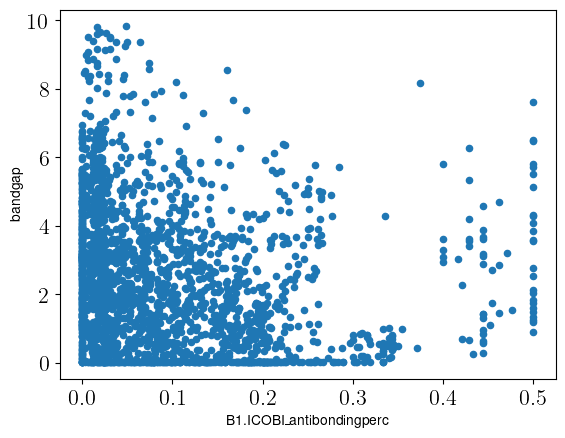

In [16]:
corr_df.plot.scatter(x='B1.ICOBI_antibondingperc',y='bandgap')